# Datathon Passos Mágicos — Modelo Preditivo de Risco de Defasagem

## 04 — Machine Learning

Este notebook desenvolve o modelo preditivo solicitado no Datathon da Associação Passos Mágicos.

O objetivo é utilizar informações conhecidas em **2023** para estimar a probabilidade de um aluno que ainda não estava defasado **entrar em situação de defasagem em 2024**.

Essa formulação temporal é importante porque evita utilizar informações do próprio período futuro para explicar o resultado que desejamos prever.

### Etapas

1. Carregamento da base temporal;
2. Definição da população elegível e da variável-alvo;
3. Feature engineering;
4. Separação entre treino e teste;
5. Pré-processamento;
6. Comparação de modelos;
7. Tratamento do desbalanceamento;
8. Ajuste do limiar de decisão;
9. Avaliação no conjunto de teste;
10. Interpretação das variáveis;
11. Exportação do modelo para uso no Streamlit.

> **Importante:** o modelo estima risco estatístico. Ele não estabelece causalidade e não deve substituir a avaliação das equipes educacional, psicológica ou psicopedagógica.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregamento da base temporal

O notebook utiliza `base_modelo_temporal.csv`, criada na etapa de tratamento.

Essa base contém os alunos presentes em 2023 e 2024 e permite relacionar características observadas em 2023 com a situação educacional no ano seguinte.

In [2]:
def localizar_arquivo(nome):
    candidatos = [
        Path("../data/processed") / nome,
        Path("data/processed") / nome,
        Path("../") / nome,
        Path(nome),
        Path("/mnt/data") / nome,
    ]

    for caminho in candidatos:
        if caminho.exists():
            return caminho.resolve()

    raise FileNotFoundError(
        f"Arquivo '{nome}' não encontrado. "
        "Verifique se ele está em data/processed/."
    )

DATA_PATH = localizar_arquivo("base_modelo_temporal.csv")

df = pd.read_csv(DATA_PATH)

print(f"Arquivo: {DATA_PATH}")
print(f"Dimensão da base: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())

Arquivo: C:\Users\chopa\OneDrive\Área de Trabalho\DATATHON 5\data\processed\base_modelo_temporal.csv
Dimensão da base: 765 linhas x 23 colunas


,ra,fase_ordem_2023,idade_2023,genero_2023,ano_ingresso_2023,instituicao_ensino_2023,inde_2023,ian_2023,ida_2023,ieg_2023,iaa_2023,ips_2023,ipp_2023,ipv_2023,nota_matematica_2023,nota_portugues_2023,nota_ingles_2023,defasagem_2023,em_defasagem_2023,defasagem_2024,alvo_defasagem_2024,elegivel_nova_defasagem_2024,entrou_em_defasagem_2024
0,RA-861,0.0000,8.0000,Feminino,2023,Pública,9.3110,10.0000,9.6000,10.0000,9.5000,8.1300,8.4375,8.9200,9.8000,9.4000,NaN,0.0000,0.0000,-1.0000,1.0000,1,1.0000
1,RA-862,0.0000,9.0000,Masculino,2023,Pública,8.2212,5.0000,8.9000,9.1000,8.5000,8.1400,7.5000,8.5850,8.5000,9.2000,NaN,-1.0000,1.0000,-2.0000,1.0000,0,NaN
2,RA-863,0.0000,7.0000,Masculino,2023,Pública,5.9298,10.0000,6.3000,7.6000,0.0000,3.1400,5.9375,6.2600,7.0000,5.5000,NaN,0.0000,0.0000,-1.0000,1.0000,1,1.0000
3,RA-867,0.0000,8.0000,Masculino,2023,Pública,8.6992,10.0000,8.9000,8.6000,9.0000,8.7600,7.5000,8.4150,8.7000,9.0000,NaN,0.0000,0.0000,-1.0000,1.0000,1,1.0000
4,RA-868,0.0000,7.0000,Masculino,2023,Pública,8.6389,10.0000,7.1000,9.5000,10.0000,8.7600,7.1875,8.6700,7.8000,6.3000,NaN,0.0000,0.0000,-1.0000,1.0000,1,1.0000


## 2. Definição do problema preditivo

O objetivo não será prever simplesmente se o aluno está defasado em 2024.

Para tornar o problema realmente preventivo, serão considerados somente alunos que **não estavam em defasagem em 2023** e que, portanto, poderiam entrar em defasagem no ciclo seguinte.

A variável-alvo utilizada será:

- `entrou_em_defasagem_2024 = 1`: aluno entrou em defasagem em 2024;
- `entrou_em_defasagem_2024 = 0`: aluno permaneceu sem defasagem.

Dessa forma, todas as variáveis explicativas utilizadas pelo modelo são conhecidas antes do resultado de 2024.

In [3]:
df_modelo = df.loc[df["elegivel_nova_defasagem_2024"] == 1].copy()

TARGET = "entrou_em_defasagem_2024"

df_modelo = df_modelo.dropna(subset=[TARGET]).copy()
df_modelo[TARGET] = df_modelo[TARGET].astype(int)

distribuicao_alvo = (
    df_modelo[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Não entrou em defasagem", 1: "Entrou em defasagem"})
    .to_frame("Quantidade")
)

distribuicao_alvo["Percentual (%)"] = (
    distribuicao_alvo["Quantidade"] / len(df_modelo) * 100
).round(2)

print(f"Alunos elegíveis para o problema preditivo: {len(df_modelo)}")
display(distribuicao_alvo)

Alunos elegíveis para o problema preditivo: 370


,Quantidade,Percentual (%)
entrou_em_defasagem_2024,,
Não entrou em defasagem,286,77.3000
Entrou em defasagem,84,22.7000


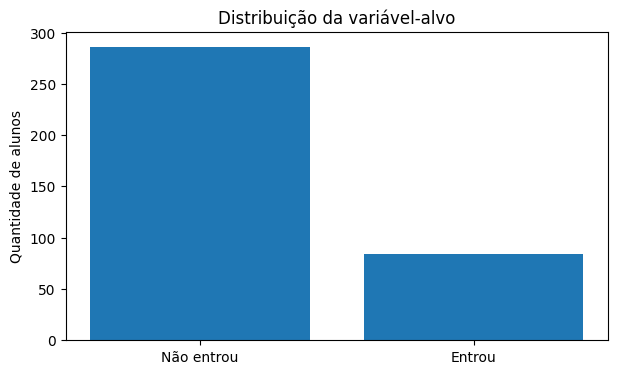

In [4]:
plt.figure(figsize=(7, 4))
contagem = df_modelo[TARGET].value_counts().sort_index()
plt.bar(["Não entrou", "Entrou"], contagem.values)
plt.title("Distribuição da variável-alvo")
plt.ylabel("Quantidade de alunos")
plt.show()

### Diagnóstico do alvo

A classe positiva representa uma parcela menor da amostra, portanto existe **desbalanceamento de classes**.

Isso significa que a acurácia isoladamente não será uma métrica adequada. Um modelo que classificasse todos os alunos como "sem risco" poderia apresentar uma acurácia aparentemente razoável, mas teria utilidade praticamente nula para a identificação preventiva.

Por isso, serão priorizadas:

- **Recall:** proporção dos alunos que realmente entraram em defasagem e foram identificados pelo modelo;
- **Precision:** proporção dos alertas emitidos que realmente se confirmaram;
- **F1:** equilíbrio entre precision e recall;
- **F2:** dá peso maior ao recall;
- **ROC-AUC:** capacidade geral de discriminação;
- **PR-AUC:** qualidade da classificação positiva em um cenário desbalanceado.

Como o objetivo é apoiar intervenção preventiva, será dada importância especial ao **recall** e ao **F2**.

## 3. Feature engineering

Além das variáveis originais de 2023, serão criadas algumas características derivadas utilizando exclusivamente informações disponíveis naquele ano.

### Novas variáveis

- `tempo_pm_2023`: quantidade aproximada de anos desde o ingresso na Passos Mágicos;
- `media_notas_2023`: média das notas acadêmicas disponíveis;
- `media_indicadores_2023`: média dos indicadores educacionais;
- `min_indicador_2023`: menor indicador observado para o aluno.

Essas variáveis resumem aspectos da trajetória e do desempenho do aluno sem utilizar dados de 2024.

In [5]:
notas = [
    "nota_matematica_2023",
    "nota_portugues_2023",
    "nota_ingles_2023",
]

indicadores = [
    "ian_2023",
    "ida_2023",
    "ieg_2023",
    "iaa_2023",
    "ips_2023",
    "ipp_2023",
    "ipv_2023",
]

df_modelo["tempo_pm_2023"] = (
    2023 - df_modelo["ano_ingresso_2023"]
).clip(lower=0)

df_modelo["media_notas_2023"] = df_modelo[notas].mean(axis=1)
df_modelo["media_indicadores_2023"] = df_modelo[indicadores].mean(axis=1)
df_modelo["min_indicador_2023"] = df_modelo[indicadores].min(axis=1)

print("Features derivadas criadas.")
display(
    df_modelo[
        [
            "ra",
            "tempo_pm_2023",
            "media_notas_2023",
            "media_indicadores_2023",
            "min_indicador_2023",
            TARGET,
        ]
    ].head()
)

Features derivadas criadas.


,ra,tempo_pm_2023,media_notas_2023,media_indicadores_2023,min_indicador_2023,entrou_em_defasagem_2024
0,RA-861,0,9.6000,9.2268,8.1300,1
2,RA-863,0,6.2500,5.6054,0.0000,1
3,RA-867,0,8.8500,8.7393,7.5000,1
4,RA-868,0,7.0500,8.7454,7.1000,1
8,RA-876,0,7.5000,8.6793,7.5000,0


## 4. Seleção das variáveis explicativas

Serão utilizadas somente informações de 2023.

Campos de 2024, o próprio alvo e identificadores administrativos não serão usados como features. Isso evita **data leakage**, isto é, o uso de informações que só estariam disponíveis depois do momento em que a previsão deveria ser realizada.

In [6]:
FEATURES = [
    "fase_ordem_2023",
    "idade_2023",
    "genero_2023",
    "ano_ingresso_2023",
    "instituicao_ensino_2023",
    "inde_2023",
    "ian_2023",
    "ida_2023",
    "ieg_2023",
    "iaa_2023",
    "ips_2023",
    "ipp_2023",
    "ipv_2023",
    "nota_matematica_2023",
    "nota_portugues_2023",
    "nota_ingles_2023",
    "defasagem_2023",
    "tempo_pm_2023",
    "media_notas_2023",
    "media_indicadores_2023",
    "min_indicador_2023",
]

X = df_modelo[FEATURES].copy()
y = df_modelo[TARGET].copy()

print(f"Quantidade de features: {len(FEATURES)}")
print(f"Registros utilizados: {len(X)}")

Quantidade de features: 21
Registros utilizados: 370


### Valores ausentes

Os valores ausentes serão tratados **dentro do pipeline de Machine Learning**, evitando que informações do conjunto de teste sejam utilizadas na preparação dos dados de treino.

- Variáveis numéricas: mediana calculada no treino;
- Variáveis categóricas: categoria mais frequente calculada no treino.

In [7]:
resumo_nulos = pd.DataFrame({
    "Nulos": X.isna().sum(),
    "Percentual (%)": (X.isna().mean() * 100).round(2),
})

resumo_nulos = resumo_nulos.loc[resumo_nulos["Nulos"] > 0].sort_values(
    "Percentual (%)",
    ascending=False
)

display(resumo_nulos)

,Nulos,Percentual (%)
nota_ingles_2023,249,67.3000
ida_2023,70,18.9200
inde_2023,70,18.9200
ieg_2023,70,18.9200
ipv_2023,70,18.9200
nota_matematica_2023,70,18.9200
ipp_2023,70,18.9200
nota_portugues_2023,70,18.9200
media_notas_2023,70,18.9200
iaa_2023,59,15.9500


## 5. Separação entre treino e teste

Será utilizada uma divisão estratificada de:

- **75% para treino**;
- **25% para teste**.

A estratificação mantém aproximadamente a mesma proporção de alunos que entraram em defasagem nos dois conjuntos.

O conjunto de teste será mantido separado durante a comparação dos modelos e o ajuste do limiar de decisão, servindo como avaliação final.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Treino: {len(X_train)} alunos")
print(f"Teste:  {len(X_test)} alunos")
print()
print("Distribuição no treino:")
display(y_train.value_counts().sort_index().to_frame("Quantidade"))
print("Distribuição no teste:")
display(y_test.value_counts().sort_index().to_frame("Quantidade"))

Treino: 277 alunos
Teste:  93 alunos

Distribuição no treino:


,Quantidade
entrou_em_defasagem_2024,
0,214
1,63


Distribuição no teste:


,Quantidade
entrou_em_defasagem_2024,
0,72
1,21


## 6. Pipeline de pré-processamento

O pipeline garante que todas as transformações sejam aprendidas apenas com os dados de treino.

### Variáveis numéricas
1. Imputação pela mediana;
2. Padronização com `StandardScaler`.

### Variáveis categóricas
1. Imputação pela moda;
2. One-Hot Encoding.

A padronização é especialmente útil para a Regressão Logística e não prejudica os modelos baseados em árvores.

In [9]:
colunas_numericas = [
    coluna for coluna in FEATURES
    if X[coluna].dtype != "object"
]

colunas_categoricas = [
    coluna for coluna in FEATURES
    if X[coluna].dtype == "object"
]

pipeline_numerico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="median")),
        ("escala", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, colunas_numericas),
        ("cat", pipeline_categorico, colunas_categoricas),
    ],
    remainder="drop",
)

print(f"Variáveis numéricas: {len(colunas_numericas)}")
print(f"Variáveis categóricas: {len(colunas_categoricas)}")

Variáveis numéricas: 19
Variáveis categóricas: 2


## 7. Comparação de modelos

Serão avaliados três algoritmos com características diferentes:

### Regressão Logística
Modelo linear, simples e interpretável. Será utilizada ponderação automática das classes.

### Random Forest
Conjunto de árvores de decisão capaz de capturar relações não lineares e interações entre variáveis.

### HistGradientBoosting
Modelo de boosting que combina sequencialmente árvores e também consegue capturar relações complexas.

Nos três casos o desbalanceamento será considerado por meio de pesos de classe.

A comparação será realizada com **validação cruzada estratificada de 5 folds somente no conjunto de treino**.

In [10]:
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

from sklearn.metrics import make_scorer

metricas_cv = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "f2": make_scorer(fbeta_score, beta=2),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

resultados = []

for nome, modelo in modelos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessador", clone(preprocessador)),
            ("modelo", clone(modelo)),
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metricas_cv,
        n_jobs=-1,
    )

    resultados.append({
        "Modelo": nome,
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean(),
        "F2": scores["test_f2"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
    })

resultados_cv = (
    pd.DataFrame(resultados)
    .sort_values(["F2", "Recall", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(resultados_cv.style.format({
    "Recall": "{:.3f}",
    "Precision": "{:.3f}",
    "F1": "{:.3f}",
    "F2": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
}))

,Modelo,Recall,Precision,F1,F2,ROC-AUC,PR-AUC
0,Random Forest,0.812,0.702,0.737,0.775,0.926,0.801
1,Regressão Logística,0.809,0.548,0.651,0.736,0.886,0.762
2,HistGradientBoosting,0.749,0.652,0.682,0.717,0.902,0.741


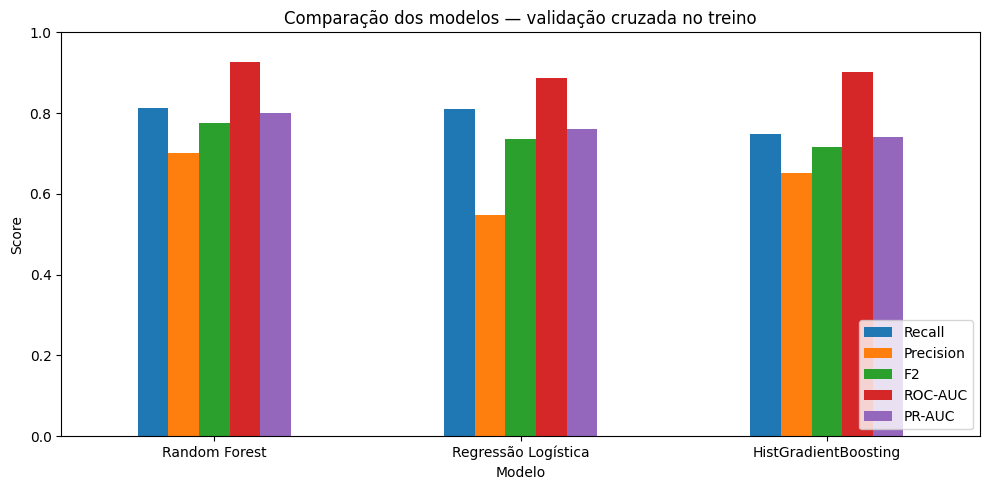

In [11]:
metricas_plot = ["Recall", "Precision", "F2", "ROC-AUC", "PR-AUC"]

ax = (
    resultados_cv
    .set_index("Modelo")[metricas_plot]
    .plot(kind="bar", figsize=(10, 5))
)

plt.title("Comparação dos modelos — validação cruzada no treino")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Seleção do modelo

O modelo será escolhido principalmente pelo **F2**, pois essa métrica dá maior peso ao recall e está alinhada ao objetivo de identificar o máximo possível de alunos que poderão precisar de intervenção.

ROC-AUC e PR-AUC também serão observados para evitar escolher um modelo que obtenha recall elevado apenas às custas de baixa capacidade de discriminação.

In [12]:
melhor_modelo_nome = resultados_cv.loc[0, "Modelo"]

print(f"Modelo selecionado pela validação cruzada: {melhor_modelo_nome}")

display(
    resultados_cv.loc[[0]].style.format({
        "Recall": "{:.3f}",
        "Precision": "{:.3f}",
        "F1": "{:.3f}",
        "F2": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}",
    })
)

Modelo selecionado pela validação cruzada: Random Forest


,Modelo,Recall,Precision,F1,F2,ROC-AUC,PR-AUC
0,Random Forest,0.812,0.702,0.737,0.775,0.926,0.801


## 8. Ajuste do limiar de decisão

Classificadores normalmente utilizam `0,50` como limiar padrão:

- probabilidade ≥ 0,50 → classe positiva;
- probabilidade < 0,50 → classe negativa.

Entretanto, no contexto deste projeto, um **falso negativo** representa um aluno que entrou em defasagem e não foi sinalizado antecipadamente.

Por isso, o limiar será escolhido utilizando apenas o conjunto de treino.

Para evitar otimização excessiva sobre os próprios dados usados no treinamento, serão geradas probabilidades **out-of-fold** por validação cruzada e o limiar que maximizar o **F2** será escolhido.

In [13]:
pipeline_selecionado = Pipeline(
    steps=[
        ("preprocessador", clone(preprocessador)),
        ("modelo", clone(modelos[melhor_modelo_nome])),
    ]
)

probabilidades_oof = cross_val_predict(
    pipeline_selecionado,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

limiares = np.arange(0.10, 0.71, 0.01)

avaliacao_limiares = []

for limiar in limiares:
    pred = (probabilidades_oof >= limiar).astype(int)

    avaliacao_limiares.append({
        "Limiar": limiar,
        "Precision": precision_score(y_train, pred, zero_division=0),
        "Recall": recall_score(y_train, pred),
        "F1": f1_score(y_train, pred),
        "F2": fbeta_score(y_train, pred, beta=2),
    })

df_limiares = pd.DataFrame(avaliacao_limiares)

melhor_linha = (
    df_limiares
    .sort_values(["F2", "Recall"], ascending=False)
    .iloc[0]
)

limiar_otimo = float(melhor_linha["Limiar"])

print(f"Limiar selecionado: {limiar_otimo:.2f}")
display(
    df_limiares
    .sort_values(["F2", "Recall"], ascending=False)
    .head(10)
    .style.format("{:.3f}")
)

Limiar selecionado: 0.41


,Limiar,Precision,Recall,F1,F2
31,0.410,0.632,0.873,0.733,0.811
6,0.160,0.488,0.968,0.649,0.809
30,0.400,0.625,0.873,0.728,0.809
8,0.180,0.504,0.952,0.659,0.809
12,0.220,0.522,0.937,0.670,0.808
29,0.390,0.618,0.873,0.724,0.806
11,0.210,0.518,0.937,0.667,0.806
7,0.170,0.496,0.952,0.652,0.804
10,0.200,0.513,0.937,0.663,0.804
32,0.420,0.643,0.857,0.735,0.804


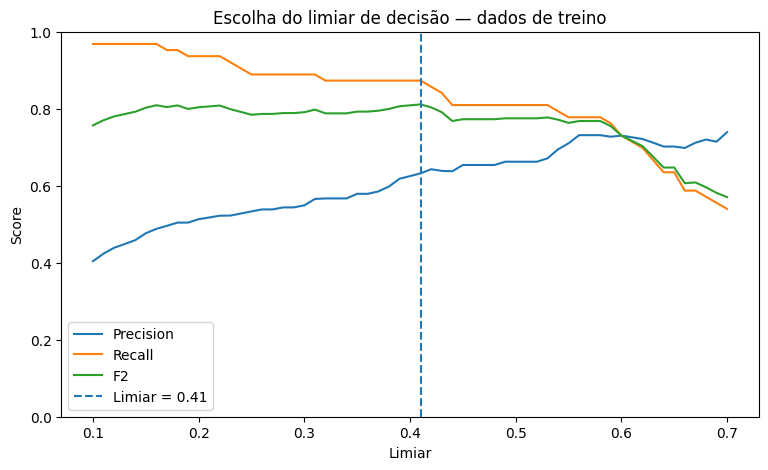

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(df_limiares["Limiar"], df_limiares["Precision"], label="Precision")
plt.plot(df_limiares["Limiar"], df_limiares["Recall"], label="Recall")
plt.plot(df_limiares["Limiar"], df_limiares["F2"], label="F2")
plt.axvline(limiar_otimo, linestyle="--", label=f"Limiar = {limiar_otimo:.2f}")
plt.title("Escolha do limiar de decisão — dados de treino")
plt.xlabel("Limiar")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

## 9. Avaliação final no conjunto de teste

Somente agora o conjunto de teste será utilizado.

O desempenho será apresentado tanto com o limiar padrão de 0,50 quanto com o limiar definido anteriormente nos dados de treino.

A comparação permite medir o custo-benefício de aumentar a sensibilidade do sistema de alerta.

In [15]:
pipeline_selecionado.fit(X_train, y_train)

prob_teste = pipeline_selecionado.predict_proba(X_test)[:, 1]

def calcular_metricas(y_real, prob, limiar):
    pred = (prob >= limiar).astype(int)

    return {
        "Limiar": limiar,
        "Accuracy": accuracy_score(y_real, pred),
        "Precision": precision_score(y_real, pred, zero_division=0),
        "Recall": recall_score(y_real, pred),
        "F1": f1_score(y_real, pred),
        "F2": fbeta_score(y_real, pred, beta=2),
        "ROC-AUC": roc_auc_score(y_real, prob),
        "PR-AUC": average_precision_score(y_real, prob),
        "Brier Score": brier_score_loss(y_real, prob),
    }

metricas_teste = pd.DataFrame([
    {
        "Cenário": "Limiar padrão",
        **calcular_metricas(y_test, prob_teste, 0.50),
    },
    {
        "Cenário": "Limiar ajustado",
        **calcular_metricas(y_test, prob_teste, limiar_otimo),
    },
])

display(
    metricas_teste.style.format({
        "Limiar": "{:.2f}",
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "F2": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}",
        "Brier Score": "{:.3f}",
    })
)

,Cenário,Limiar,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,Brier Score
0,Limiar padrão,0.50,0.892,0.720,0.857,0.783,0.826,0.953,0.858,0.078
1,Limiar ajustado,0.41,0.871,0.655,0.905,0.760,0.841,0.953,0.858,0.078


In [16]:
pred_teste = (prob_teste >= limiar_otimo).astype(int)

print("Classification report — limiar ajustado")
print()
print(
    classification_report(
        y_test,
        pred_teste,
        target_names=["Não entrou", "Entrou"],
        digits=3,
    )
)

Classification report — limiar ajustado

              precision    recall  f1-score   support

  Não entrou      0.969     0.861     0.912        72
      Entrou      0.655     0.905     0.760        21

    accuracy                          0.871        93
   macro avg      0.812     0.883     0.836        93
weighted avg      0.898     0.871     0.877        93



### Matriz de confusão

Para este projeto, o quadrante de maior preocupação é o de **falsos negativos**: alunos que efetivamente entraram em defasagem, mas não foram sinalizados.

O ajuste do limiar busca reduzir justamente esse tipo de erro.

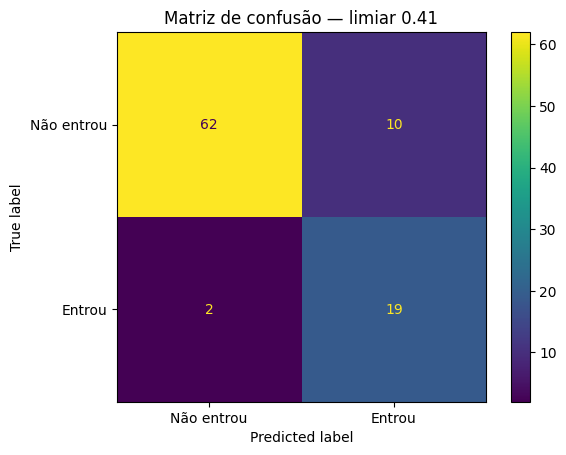

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_teste,
    display_labels=["Não entrou", "Entrou"],
)

plt.title(f"Matriz de confusão — limiar {limiar_otimo:.2f}")
plt.show()

### Curvas ROC e Precision-Recall

A curva ROC mostra a capacidade geral de discriminar as duas classes em diferentes limiares.

Como a classe positiva é minoritária, a curva **Precision-Recall** também é especialmente relevante neste problema.

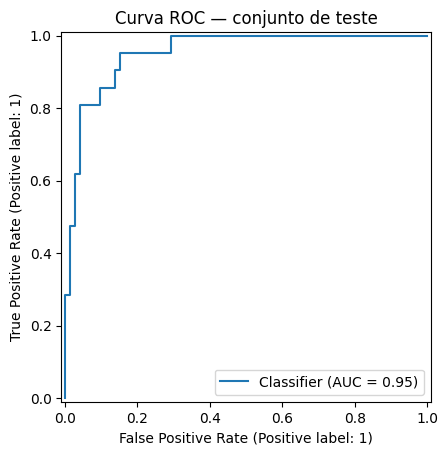

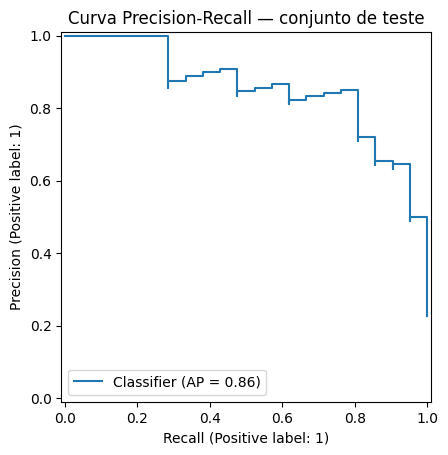

In [18]:
RocCurveDisplay.from_predictions(y_test, prob_teste)
plt.title("Curva ROC — conjunto de teste")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, prob_teste)
plt.title("Curva Precision-Recall — conjunto de teste")
plt.show()

## 10. Interpretação das variáveis

Para compreender quais informações contribuem mais para o poder preditivo, será utilizada **Permutation Importance** no conjunto de teste.

Essa técnica mede quanto a capacidade de discriminação do modelo piora quando os valores de uma variável são embaralhados.

A importância deve ser interpretada como **importância preditiva**, e não como efeito causal.

In [19]:
permutacao = permutation_importance(
    pipeline_selecionado,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_features = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importancia_media": permutacao.importances_mean,
        "Desvio_padrao": permutacao.importances_std,
    })
    .sort_values("Importancia_media", ascending=False)
    .reset_index(drop=True)
)

display(
    importancia_features.head(15).style.format({
        "Importancia_media": "{:.4f}",
        "Desvio_padrao": "{:.4f}",
    })
)

,Feature,Importancia_media,Desvio_padrao
0,idade_2023,0.0295,0.0105
1,fase_ordem_2023,0.0185,0.0086
2,ipv_2023,0.0108,0.0043
3,ipp_2023,0.0087,0.0057
4,ano_ingresso_2023,0.0037,0.0058
5,min_indicador_2023,0.0036,0.0025
6,iaa_2023,0.0030,0.0023
7,ips_2023,0.0027,0.0033
8,ieg_2023,0.0021,0.0013
9,nota_matematica_2023,0.0019,0.0024


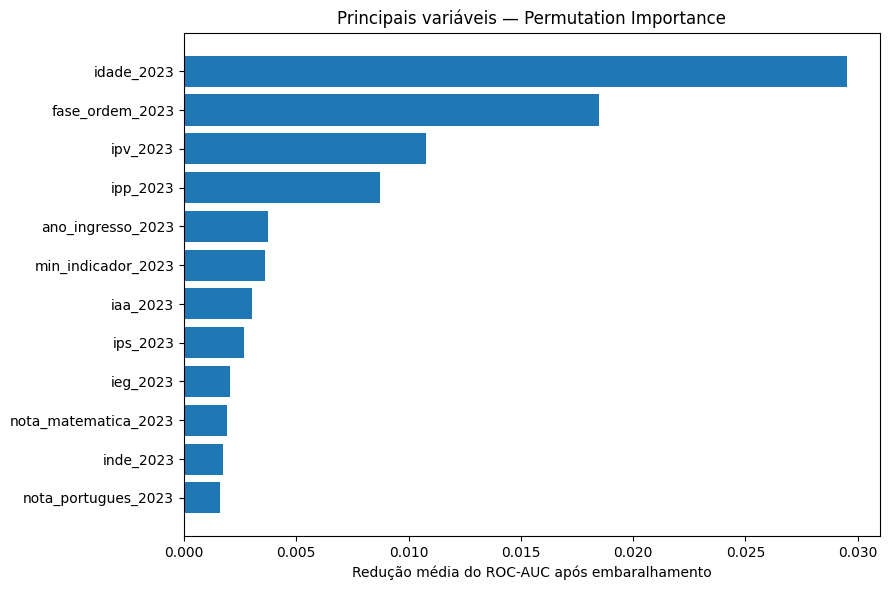

In [20]:
top_importancias = importancia_features.head(12).sort_values(
    "Importancia_media",
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(top_importancias["Feature"], top_importancias["Importancia_media"])
plt.title("Principais variáveis — Permutation Importance")
plt.xlabel("Redução média do ROC-AUC após embaralhamento")
plt.tight_layout()
plt.show()

## 11. Análise das probabilidades estimadas

Além da classificação binária, o modelo gera uma probabilidade estimada de entrada em defasagem.

Essa probabilidade poderá ser utilizada no Streamlit para **priorização de acompanhamento**, permitindo ordenar alunos do maior para o menor risco estimado.

O valor não deve ser interpretado como certeza individual. Trata-se de uma estimativa baseada no padrão histórico observado.

In [21]:
resultado_teste = df_modelo.loc[X_test.index, ["ra"]].copy()

resultado_teste["probabilidade_risco"] = prob_teste
resultado_teste["classificacao_modelo"] = pred_teste
resultado_teste["resultado_real"] = y_test.values

resultado_teste = resultado_teste.sort_values(
    "probabilidade_risco",
    ascending=False
)

display(
    resultado_teste.head(20).style.format({
        "probabilidade_risco": "{:.1%}"
    })
)

,ra,probabilidade_risco,classificacao_modelo,resultado_real
66,RA-925,98.5%,1,1
59,RA-920,94.5%,1,1
166,RA-1006,92.4%,1,1
13,RA-885,88.9%,1,1
139,RA-975,87.8%,1,1
100,RA-949,87.8%,1,1
105,RA-952,87.8%,1,0
142,RA-979,86.8%,1,1
79,RA-930,83.2%,1,1
205,RA-1035,82.7%,1,1


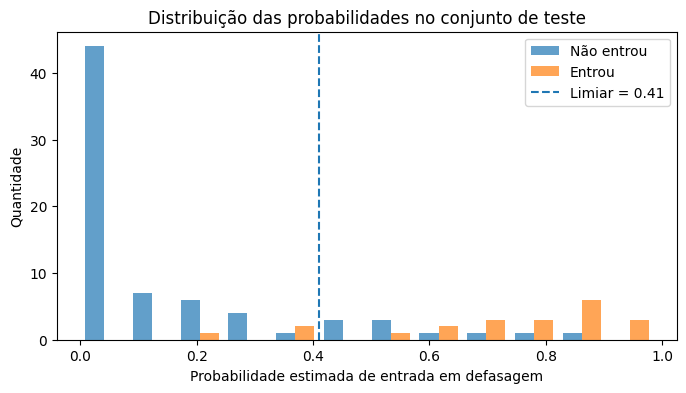

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(
    [
        prob_teste[y_test.values == 0],
        prob_teste[y_test.values == 1],
    ],
    bins=12,
    label=["Não entrou", "Entrou"],
    alpha=0.7,
)
plt.axvline(limiar_otimo, linestyle="--", label=f"Limiar = {limiar_otimo:.2f}")
plt.title("Distribuição das probabilidades no conjunto de teste")
plt.xlabel("Probabilidade estimada de entrada em defasagem")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

## 12. Exportação do modelo

Após a avaliação final, o modelo será treinado novamente utilizando toda a população elegível disponível.

Esse modelo será utilizado posteriormente pelo aplicativo Streamlit.

Serão salvos:

- `models/modelo_risco.joblib`: pipeline treinado e limiar de decisão;
- `models/modelo_risco_metadata.json`: informações sobre o modelo;
- `data/processed/metricas_modelo.csv`: métricas finais;
- `data/processed/importancia_features.csv`: importância das variáveis;
- `data/processed/predicoes_teste_modelo.csv`: previsões realizadas no conjunto de teste.

O pipeline salvo espera receber as mesmas features utilizadas neste notebook, incluindo as features derivadas.

In [23]:
# Identificação da raiz do projeto
if DATA_PATH.parent.name == "processed" and DATA_PATH.parent.parent.name == "data":
    PROJECT_ROOT = DATA_PATH.parents[2]
else:
    PROJECT_ROOT = Path.cwd().resolve()

MODELS_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Refit em toda a população elegível após a avaliação final
modelo_deploy = Pipeline(
    steps=[
        ("preprocessador", clone(preprocessador)),
        ("modelo", clone(modelos[melhor_modelo_nome])),
    ]
)

modelo_deploy.fit(X, y)

bundle = {
    "pipeline": modelo_deploy,
    "threshold": limiar_otimo,
    "features": FEATURES,
    "target": TARGET,
    "feature_engineering": {
        "tempo_pm_2023": "2023 - ano_ingresso_2023, limitado a mínimo 0",
        "media_notas_2023": "média de Matemática, Português e Inglês disponíveis",
        "media_indicadores_2023": "média de IAN, IDA, IEG, IAA, IPS, IPP e IPV",
        "min_indicador_2023": "menor valor entre IAN, IDA, IEG, IAA, IPS, IPP e IPV",
    },
}

MODEL_PATH = MODELS_DIR / "modelo_risco.joblib"
joblib.dump(bundle, MODEL_PATH)

metricas_ajustadas = (
    metricas_teste
    .loc[metricas_teste["Cenário"] == "Limiar ajustado"]
    .iloc[0]
)

metadata = {
    "modelo": melhor_modelo_nome,
    "target": TARGET,
    "threshold": float(limiar_otimo),
    "n_amostras": int(len(X)),
    "taxa_classe_positiva": float(y.mean()),
    "random_state": RANDOM_STATE,
    "features": FEATURES,
    "metricas_teste": {
        "accuracy": float(metricas_ajustadas["Accuracy"]),
        "precision": float(metricas_ajustadas["Precision"]),
        "recall": float(metricas_ajustadas["Recall"]),
        "f1": float(metricas_ajustadas["F1"]),
        "f2": float(metricas_ajustadas["F2"]),
        "roc_auc": float(metricas_ajustadas["ROC-AUC"]),
        "pr_auc": float(metricas_ajustadas["PR-AUC"]),
        "brier_score": float(metricas_ajustadas["Brier Score"]),
    },
}

METADATA_PATH = MODELS_DIR / "modelo_risco_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as arquivo:
    json.dump(metadata, arquivo, ensure_ascii=False, indent=2)

metricas_teste.to_csv(
    PROCESSED_DIR / "metricas_modelo.csv",
    index=False,
)

importancia_features.to_csv(
    PROCESSED_DIR / "importancia_features.csv",
    index=False,
)

resultado_teste.to_csv(
    PROCESSED_DIR / "predicoes_teste_modelo.csv",
    index=False,
)

print(f"Modelo salvo em: {MODEL_PATH}")
print(f"Metadata salva em: {METADATA_PATH}")
print(f"Arquivos auxiliares salvos em: {PROCESSED_DIR}")

Modelo salvo em: C:\Users\chopa\OneDrive\Área de Trabalho\DATATHON 5\models\modelo_risco.joblib
Metadata salva em: C:\Users\chopa\OneDrive\Área de Trabalho\DATATHON 5\models\modelo_risco_metadata.json
Arquivos auxiliares salvos em: C:\Users\chopa\OneDrive\Área de Trabalho\DATATHON 5\data\processed


# 13. Resultados e conclusão

O problema preditivo foi construído com **370 alunos que estavam sem defasagem em 2023** e possuíam acompanhamento em 2024.

Desses alunos:

- **286 (77,3%)** permaneceram sem defasagem;
- **84 (22,7%)** entraram em defasagem em 2024.

A comparação por validação cruzada no conjunto de treino indicou o **Random Forest** como o modelo mais equilibrado para o objetivo do projeto.

Na validação cruzada, aproximadamente:

- **Recall:** 0,812;
- **Precision:** 0,702;
- **F2:** 0,775;
- **ROC-AUC:** 0,926;
- **PR-AUC:** 0,801.

O limiar de decisão foi definido **somente com os dados de treino**, utilizando probabilidades out-of-fold e priorizando o F2. O limiar selecionado foi aproximadamente **0,41**.

No conjunto de teste independente, utilizando esse limiar, o modelo obteve aproximadamente:

- **Accuracy:** 0,871;
- **Precision:** 0,655;
- **Recall:** 0,905;
- **F1:** 0,760;
- **F2:** 0,841;
- **ROC-AUC:** 0,953;
- **PR-AUC:** 0,858;
- **Brier Score:** 0,078.

Entre os **21 alunos do conjunto de teste que efetivamente entraram em defasagem**, o modelo identificou **19**, deixando **2 falsos negativos**. Em contrapartida, foram gerados **10 falsos positivos**, o que representa o custo de aumentar a sensibilidade do sistema de alerta.

Esse comportamento é coerente com a finalidade proposta: utilizar o modelo como uma ferramenta de **triagem preventiva**, priorizando alunos para análise humana mais detalhada.

## Principais variáveis preditivas

A análise de permutation importance indicou que variáveis como:

- idade;
- fase;
- IPV;
- tempo/ano de ingresso;
- IPP;

contribuem de forma relevante para a discriminação do risco no conjunto de teste.

Essas relações são **preditivas e não causais**.

## Limitações

Os resultados devem ser interpretados considerando algumas limitações:

1. A amostra do problema temporal possui apenas **370 alunos**;
2. Existe somente uma transição completa disponível para esse desenho: **2023 → 2024**;
3. O desempenho foi medido em uma divisão interna dos mesmos dados históricos, sem validação em uma coorte externa;
4. A classe de interesse representa aproximadamente 23% dos casos;
5. Algumas variáveis possuem quantidade relevante de valores ausentes;
6. As probabilidades são estimativas do modelo e não garantias individuais;
7. O modelo deve apoiar, e não substituir, a avaliação das equipes da Passos Mágicos.

## Próxima etapa

O artefato `modelo_risco.joblib` pode agora ser integrado ao **Streamlit**, permitindo que a Passos Mágicos informe os indicadores de um aluno e obtenha:

- probabilidade estimada de risco;
- sinalização preventiva;
- principais informações utilizadas na previsão.

O aplicativo deverá deixar claro que o resultado é uma ferramenta de apoio à decisão e não uma decisão automática sobre o aluno.